In [10]:
from pathlib import Path
import sys

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    accuracy_score,
    balanced_accuracy_score,
    classification_report,
    confusion_matrix,
    f1_score,
    roc_auc_score,
)

# Run with cwd = csi_pipeline/ (recommended)
PIPE = Path.cwd()
if not (PIPE / "csi_features.py").exists():
    PIPE = Path.cwd() / "csi_pipeline"
sys.path.insert(0, str(PIPE))

from csi_features import (
    FEATURE_VERSION,
    LABEL_EMPTY,
    LABEL_OBJECT,
    WindowSpec,
    compute_baseline_phase_profile,
    compute_baseline_profile,
)
from train_object_detector import (
    blocked_split,
    build_pipeline,
    build_windows,
    load_packets,
    save_bundle,
    select_best_model,
    tune_threshold,
)

REPO = PIPE.parent
CSV_PATH = REPO / "sample data " / "csi_packets.csv"
MODEL_OUT = PIPE / "models" / "object_detector.joblib"

WINDOW = 30
STRIDE = 15
TEST_FRACTION = 0.2
SEED = 42
DEPLOY_ON_ALL = True  # retrain best model on all windows after hold-out eval

print(f"pipeline dir: {PIPE}")
print(f"csv: {CSV_PATH}")
print(f"feature version: v{FEATURE_VERSION}")

pipeline dir: /Users/saikarthik/Desktop/camera_module/csi_pipeline
csv: /Users/saikarthik/Desktop/camera_module/sample data /csi_packets.csv
feature version: v3


In [11]:
assert CSV_PATH.is_file(), f"CSV not found: {CSV_PATH}"

packets, labels, sessions = load_packets(CSV_PATH)
print(f"packets: {len(packets):,}")
print(f"  empty:  {labels.count(LABEL_EMPTY):,}")
print(f"  object: {labels.count(LABEL_OBJECT):,}")
print(f"sessions: {sorted(set(sessions))}")

skip bad iq row: expected 234 iq ints, got 76
skip bad iq row: expected 234 iq ints, got 364
skip bad iq row: expected 234 iq ints, got 282
skip bad iq row: expected 234 iq ints, got 347


packets: 34,045
  empty:  16,842
  object: 17,207
sessions: ['baseline_1hr', 'object_1hr']


In [12]:
baseline_profile = compute_baseline_profile(packets, labels)
baseline_phase = compute_baseline_phase_profile(packets, labels)
spec = WindowSpec(size=WINDOW, stride=STRIDE)

X, y, meta = build_windows(
    packets, labels, sessions, spec, baseline_profile, baseline_phase
)

print(f"windows: {len(y):,}  features: {X.shape[1]}  (v{FEATURE_VERSION})")
print(f"class balance: empty={int((y == 0).sum())}  object={int((y == 1).sum())}")

pd.Series(meta).value_counts()

windows: 2,268  features: 4460  (v3)
class balance: empty=1122  object=1146


object_1hr      1145
baseline_1hr    1123
Name: count, dtype: int64

In [13]:
X_train, X_test, y_train, y_test = blocked_split(
    X, y, meta, test_fraction=TEST_FRACTION, seed=SEED
)
print(f"train: {len(y_train):,}  hold-out: {len(y_test):,}")

train: 1,814  hold-out: 454


In [14]:
model_name, eval_pipe, threshold, model_scores = select_best_model(
    X_train, y_train, X_test, y_test
)

scores_df = pd.Series(model_scores, name="bal_acc").sort_values(ascending=False)
print("Model selection (balanced accuracy on hold-out):")
display(scores_df.to_frame())
print(f"\nSelected: {model_name}  threshold={threshold:.2f}")

  candidate hgb: min_recall=0.759  bal_acc=0.879  thr=0.38


Model selection (balanced accuracy on hold-out):


  candidate rf: min_recall=0.763  bal_acc=0.882  thr=0.84
  candidate logreg: min_recall=0.772  bal_acc=0.886  thr=0.15


,bal_acc
logreg,0.886161
rf,0.881696
hgb,0.879464



Selected: logreg  threshold=0.15


accuracy             0.887665
balanced_accuracy    0.886161
object_f1            0.900196
empty_f1             0.871537
roc_auc              0.999864
Name: hold-out, dtype: float64

              precision    recall  f1-score   support

       empty       1.00      0.77      0.87       224
      object       0.82      1.00      0.90       230

    accuracy                           0.89       454
   macro avg       0.91      0.89      0.89       454
weighted avg       0.91      0.89      0.89       454



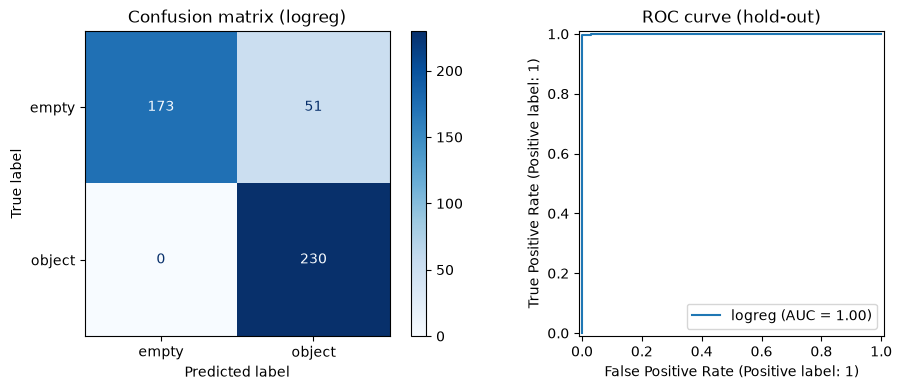

In [15]:
proba_test = eval_pipe.predict_proba(X_test)[:, LABEL_OBJECT]
pred_test = (proba_test >= threshold).astype(int)

metrics = {
    "accuracy": float(accuracy_score(y_test, pred_test)),
    "balanced_accuracy": float(balanced_accuracy_score(y_test, pred_test)),
    "object_f1": float(f1_score(y_test, pred_test, pos_label=LABEL_OBJECT, zero_division=0)),
    "empty_f1": float(f1_score(y_test, pred_test, pos_label=LABEL_EMPTY, zero_division=0)),
}
if len(np.unique(y_test)) > 1:
    metrics["roc_auc"] = float(roc_auc_score(y_test, proba_test))

display(pd.Series(metrics, name="hold-out"))
print(classification_report(y_test, pred_test, target_names=["empty", "object"]))

cm = confusion_matrix(y_test, pred_test, labels=[LABEL_EMPTY, LABEL_OBJECT])
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
ConfusionMatrixDisplay(cm, display_labels=["empty", "object"]).plot(ax=axes[0], cmap="Blues")
axes[0].set_title(f"Confusion matrix ({model_name})")
RocCurveDisplay.from_predictions(y_test, proba_test, ax=axes[1], name=model_name)
axes[1].set_title("ROC curve (hold-out)")
plt.tight_layout()
plt.show()

In [16]:
# FORCE_MODEL = "logreg"  # logreg | rf | hgb
# pipe = build_pipeline(FORCE_MODEL)
# pipe.fit(X_train, y_train)
# proba = pipe.predict_proba(X_test)[:, LABEL_OBJECT]
# threshold, _ = tune_threshold(y_test, proba)
# model_name, eval_pipe = FORCE_MODEL, pipe

In [17]:
if DEPLOY_ON_ALL:
    print(f"Retraining {model_name} on all {len(y):,} windows …")
    pipe = build_pipeline(model_name)
    pipe.fit(X, y)
else:
    pipe = eval_pipe

save_bundle(
    MODEL_OUT,
    pipe=pipe,
    spec=spec,
    baseline_profile=baseline_profile,
    baseline_phase=baseline_phase,
    threshold=threshold,
    model_type=model_name,
    csv_path=CSV_PATH,
    metrics=metrics,
)
print(f"Saved → {MODEL_OUT}")
print("Live:  cd csi_pipeline && ./run_detect.sh --fast --quiet")

Retraining logreg on all 2,268 windows …
Saved → /Users/saikarthik/Desktop/camera_module/csi_pipeline/models/object_detector.joblib
Live:  cd csi_pipeline && ./run_detect.sh --fast --quiet


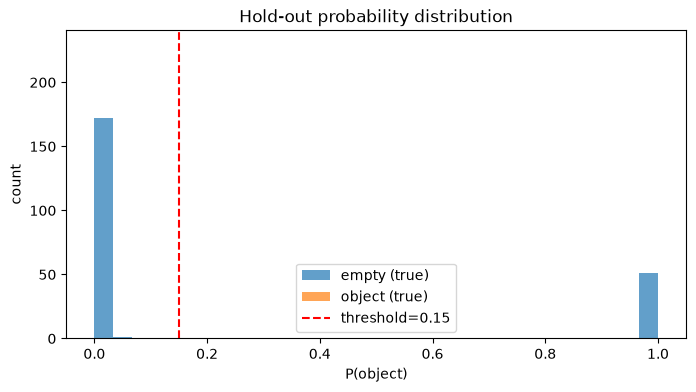

In [18]:
fig, ax = plt.subplots(figsize=(8, 4))
ax.hist(proba_test[y_test == 0], bins=30, alpha=0.7, label="empty (true)")
ax.hist(proba_test[y_test == 1], bins=30, alpha=0.7, label="object (true)")
ax.axvline(threshold, color="red", linestyle="--", label=f"threshold={threshold:.2f}")
ax.set_xlabel("P(object)")
ax.set_ylabel("count")
ax.set_title("Hold-out probability distribution")
ax.legend()
plt.show()